---

[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppestana-supervisor/PDI_python/blob/main/topico2/Topico2.ipynb)

> **Nota importante**
>
> Este notebook é carregado diretamente a partir do repositório oficial no GitHub e é apenas para **leitura**.  
> As alterações **não ficam guardadas**.
>
> Para guardar uma versão pessoal:
> - No Colab, ir a **Ficheiro → Guardar uma cópia no Drive**.  
> - A cópia ficará disponível em `O meu Drive / Colab Notebooks`.
>
> Para colaboração:
> - Abrir a versão pessoal no Google Drive.  
> - Clicar em **Partilhar** → **Qualquer pessoa com o link pode editar** (ou adicionar os colegas manualmente).  
> - A partir daí, todos podem editar em tempo real, como num Google Docs.
>
> Para guardar resultados (imagens, ficheiros, etc.) no  Drive:
> ```python
> from google.colab import drive
> drive.mount('/content/drive')
> ```
> Depois gravar, por exemplo, em:
> ```python
> img.save('/content/drive/MyDrive/PDI_outputs/resultado.png')
> ```

---

# 4.3 Morfologia Matemática

A **Morfologia Matemática** é um ramo do processamento de imagens que se baseia em conceitos da teoria dos conjuntos para analisar e manipular a **forma** e a **estrutura** dos objetos representados.  
Diferentemente dos métodos puramente numéricos (como a filtragem linear ou o cálculo de gradientes), as operações morfológicas atuam de forma **geométrica e espacial**, modificando diretamente as regiões da imagem em função de uma **forma de referência** — o **elemento estruturante**.

Um **elemento estruturante** é uma pequena máscara (ou janela) que define a vizinhança sobre a qual cada operação é aplicada. A sua forma (por exemplo, quadrada, cruz ou disco) e o seu tamanho determinam o tipo e a intensidade da transformação efetuada.

As operações fundamentais são:
- **Erosão** — reduz o tamanho das regiões brancas, removendo píxeis das bordas;  
  formalmente, $A \ominus B = \{ z \mid B_z \subseteq A \}$.
- **Dilatação** — expande as regiões brancas, adicionando píxeis às bordas;  
  formalmente, $A \oplus B = \{ z \mid (B)_z \cap A \neq \emptyset \}$.
- **Abertura** — erosão seguida de dilatação: elimina ruído e suaviza contornos pequenos.  
- **Fecho** — dilatação seguida de erosão: preenche pequenas falhas e conecta regiões próximas.

Estas operações podem ser combinadas para formar transformações mais avançadas, como **gradiente morfológico**, **top-hat**, **reconstrução por dilatação**, **esqueleto** ou **transformações condicionais**, permitindo extrair informação sobre forma, tamanho, conectividade e relações espaciais entre objetos.

Enquanto a filtragem linear atua sobre intensidades, a morfologia atua sobre **estruturas**, tornando-a especialmente útil em tarefas de **limpeza, segmentação e análise de forma**.

Neste capítulo, os principais operadores morfológicos são reimplementados manualmente — a partir dos princípios teóricos — de modo a ilustrar o funcionamento interno das operações e o papel do elemento estruturante.  
Tal como nos capítulos anteriores, estas versões são **pedagógicas e simplificadas**, focadas em transmitir a lógica matemática e não em reproduzir a eficiência das implementações otimizadas disponíveis em bibliotecas como *OpenCV* ou *scikit-image*.

## 4.3.1. Importar bibliotecas essenciais

Nesta célula inicial são importadas as bibliotecas fundamentais e definidas funções auxiliares que serão reutilizadas ao longo do notebook. Para além disso, são criadas várias imagens sintéticas — simples, geométricas e ruidosas — e importadas imagens reais destinadas à aplicação prática dos conceitos de morfologia matemática e segmentação.

#### Bibliotecas

**NumPy** é usada para operações matriciais e geração de padrões sintéticos.  
**OpenCV (cv2)** fornece funções para manipulação e desenho de formas, bem como operações morfológicas otimizadas.  
**Matplotlib** é utilizada para visualização de imagens e resultados intermédios.  
**Pillow (PIL)** permite carregar imagens externas e convertê-las para tons de cinzento.  
O módulo **scikit-image** é usado para aceder a imagens de exemplo (`data`), rotular e medir propriedades de regiões (`measure`), realizar conversões de cor (`color`) e aplicar operações morfológicas (`morphology`).  
**SciPy**, através do módulo `ndimage`, fornece funções adicionais para filtragem e transformações espaciais.  
Por fim, **threshold_otsu** é importado especificamente para binarização automática baseada em histograma.

#### Funções Auxiliares

- **`struct_element(shape, size)`**: cria elementos estruturantes binários usados nas operações morfológicas.  
  Suporta três formas:
  - `'cross'` — estrutura em cruz, útil para erosões e dilatações direcionais;
  - `'square'` — matriz cheia, aplicada em operações isotrópicas simples;
  - `'disk'` — aproximação circular obtida via máscara radial, ideal para suavizar efeitos de cantos.  
  A função levanta um erro se for passada uma forma não reconhecida.

- **`binarize_manual(img, T)`**: converte uma imagem em binária, aplicando um limiar fixo `T`.  
  É usada para demonstrar a diferença entre limiarização manual e automática (como Otsu).

#### Criação de Imagens Sintéticas

São geradas várias imagens elementares que permitem ilustrar comportamentos específicos das operações morfológicas:
- `img_square` — quadrado branco sobre fundo preto, ideal para testar erosão e dilatação.  
- `ring` — anel binário criado pela diferença entre duas máscaras circulares, usado para exemplos de gradiente e reconstrução morfológica.  
- `img_noise` — padrão binário aleatório, útil para demonstrar operações de limpeza (abertura e fecho).

#### Imagens Importadas

As imagens seguintes representam casos práticos de análise:
- `img_text` — texto de referência do *scikit-image*, utilizado para demonstrar operações de esqueletonização e contorno.  
- `img_coins` — imagem clássica para segmentação de objetos sobrepostos.  
- `img_building` — fotografia em tons de cinzento de uma fachada, com linhas e padrões geométricos nítidos.  
- `img_man` — retrato genérico em RGB, usado em exemplos de morfologia aplicada a canais de cor.  
- `img_cells` — imagem microscópica de células, adequada para ilustração de segmentação e contagem de objetos biológicos.

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from skimage import data, measure, color, morphology
import scipy.ndimage
from skimage.filters import threshold_otsu

def struct_element(shape, size):
    if shape == 'cross':
        selem = np.zeros((size, size), dtype=np.uint8)
        selem[size//2, :] = 1
        selem[:, size//2] = 1
        return selem
    elif shape == 'square':
        return np.ones((size, size), dtype=np.uint8)
    elif shape == 'disk':
        X, Y = np.ogrid[:size, :size]
        mask = (X - size//2) ** 2 + (Y - size//2) ** 2 <= (size//2) ** 2
        return mask.astype(np.uint8)
    else:
        raise ValueError('Forma desconhecida')
        
def binarize_manual(img, T):
    return (img > T).astype(np.uint8)

size_s = 16
img_square = np.zeros((size_s, size_s), dtype=np.uint8)
img_square[size_s//4:3*size_s//4, size_s//4:3*size_s//4] = 1
size_r = 128 
X, Y = np.ogrid[:size_r, :size_r] 
outer = (X - size_r//2) ** 2 + (Y - size_r//2) ** 2 <= (size_r//3) ** 2 
inner = (X - size_r//2) ** 2 + (Y - size_r//2) ** 2 <= (size_r//6) ** 2 
ring = (outer.astype(np.uint8) - inner.astype(np.uint8))
size_n = 64
img_noise = (np.random.rand(size_n, size_n) > 0.3).astype(np.uint8)


img_text = (data.text() if hasattr(data, 'text') else data.coins()).astype(np.uint8)
img_coins = data.coins().astype(np.uint8)
img_building = np.array(Image.open("imgs/building1.png").convert("L"))
img_man = np.array(Image.open("imgs/face_tgt.png"))
img_cells = np.array(Image.open("imgs/cells.png").convert("L"))


## 4.3.2. Implementar erosão e dilatação binária manual

Esta célula introduz as **operações morfológicas fundamentais** — **erosão** e **dilatação** —, comparando implementações manuais em Python com as versões otimizadas da biblioteca **OpenCV**.  
Trata-se de um dos blocos centrais do *Processamento Morfológico Binário*, usado para manipular a forma e estrutura dos objetos em imagens binarizadas.

**Descrição sequencial do código**  
1) São definidas duas funções principais:  
   - `erode_manual(img, selem)`: percorre a imagem binária e, para cada píxel, verifica se **todos** os elementos estruturantes ativos (`selem == 1`) estão sobre píxeis de valor 1. Se sim, o píxel central é mantido. Caso contrário, é removido.  
     — Esta operação **contrai** as regiões brancas, eliminando pequenos detalhes e ruído.  
   - `dilate_manual(img, selem)`: inversamente, verifica se **algum** elemento ativo do elemento estruturante coincide com um píxel de valor 1, preenchendo o píxel central.  
     — Esta operação **expande** as regiões brancas, preenchendo falhas e conectando componentes próximos.  
   Ambas as funções utilizam *padding* zero e varrem a imagem com janelas do tamanho do elemento estruturante.  

2) O elemento estruturante (`se`) é criado como um quadrado 3×3 com `struct_element('square', 3)`, equivalente ao kernel morfológico básico.  
3) A imagem de entrada (`imageIn`) é convertida para binário (`img_bin`) se ainda não estiver normalizada (valores 0/1).  
4) Aplicam-se as versões manuais das operações:  
   - `eroded_manual` e `dilated_manual`.  
5) Em paralelo, aplicam-se as **versões OpenCV** (`cv2.erode`, `cv2.dilate`), para comparação direta.  
   - O kernel é definido com `cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))`.  
   - A imagem é convertida para `uint8` (0–255), e o resultado reconvertido para binário (0/1) após a operação.  

6) Os resultados são exibidos num **painel 2×3**:
   - Primeira linha: erosão (original, manual, OpenCV).  
   - Segunda linha: dilatação (original, manual, OpenCV).  
   Todos os subplots usam tons invertidos (`gray_r`) para melhor contraste, e são estilizados com bordas discretas (#444).  

**Interpretação e observações**  
As operações morfológicas são ferramentas **não lineares** que atuam diretamente sobre a geometria da imagem:  
- A **erosão** remove píxeis de contorno e reduz pequenas regiões, útil para limpar ruído ou separar objetos conectados.  
- A **dilatação** adiciona píxeis de contorno e aumenta regiões, útil para preencher buracos e conectar componentes.  

A comparação entre as versões **manual** e **cv2** mostra a equivalência conceitual — ambas produzem resultados idênticos —, mas também evidencia a **diferença de desempenho**: as funções OpenCV estão altamente otimizadas em C/C++, sendo muito mais rápidas para imagens de grandes dimensões.

Em síntese, esta célula demonstra que:
- as operações morfológicas podem ser entendidas intuitivamente como **varrimentos locais condicionais**,  
- e que a sua implementação manual ajuda a compreender a mecânica dos algoritmos subjacentes, antes de recorrer a bibliotecas de alto desempenho.

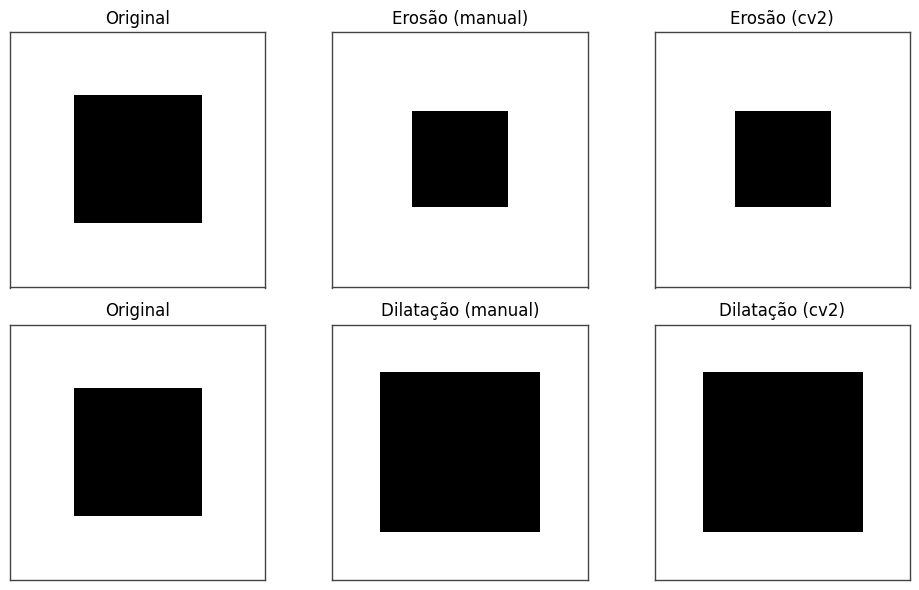

In [2]:
def erode_manual(img, selem):
    pad_h, pad_w = selem.shape[0] // 2, selem.shape[1] // 2
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    out = np.zeros_like(img)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i + selem.shape[0], j:j + selem.shape[1]]
            if np.all(region[selem == 1] == 1):
                out[i, j] = 1
    return out

def dilate_manual(img, selem):
    pad_h, pad_w = selem.shape[0] // 2, selem.shape[1] // 2
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    out = np.zeros_like(img)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i + selem.shape[0], j:j + selem.shape[1]]
            if np.any(region[selem == 1] == 1):
                out[i, j] = 1
    return out

imageIn = img_square
se = struct_element('square', 3)

img_bin = imageIn.copy()
if img_bin.max() > 1:
    img_bin = binarize_manual(img_bin, 128)

eroded_manual = erode_manual(img_bin, se)
dilated_manual = dilate_manual(img_bin, se)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
img_u8 = (img_bin * 255).astype(np.uint8)
eroded_cv2 = cv2.erode(img_u8, kernel, iterations=1)
dilated_cv2 = cv2.dilate(img_u8, kernel, iterations=1)
eroded_cv2 = (eroded_cv2 > 0).astype(np.uint8)
dilated_cv2 = (dilated_cv2 > 0).astype(np.uint8)

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
titles = [
    'Original', 'Erosão (manual)', 'Erosão (cv2)',
    'Original', 'Dilatação (manual)', 'Dilatação (cv2)'
]
images = [
    img_bin, eroded_manual, eroded_cv2,
    img_bin, dilated_manual, dilated_cv2
]
for ax, img, title in zip(axes.ravel(), images, titles):
    ax.imshow(img, cmap='gray_r', vmin=0, vmax=1, interpolation='nearest')
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')
        spine.set_linewidth(1)
plt.tight_layout()
plt.show()

## 4.3.3. Erosão e dilatação por biblioteca

Esta célula amplia o estudo das **operações morfológicas básicas** — erosão e dilatação — explorando o **efeito do tamanho do elemento estruturante** e do **número de iterações**.  
A imagem binarizada (`img_building`) serve de exemplo realista, permitindo observar como as estruturas visuais respondem a diferentes parâmetros.

**Descrição sequencial do código**  
1) A imagem é convertida para binária com `binarize_manual(imageIn, 128)` e normalizada para o intervalo [0, 255].  
2) Definem-se dois **elementos estruturantes (kernels)** distintos:
   - `kern_small`: quadrado 3×3 (estrutura mínima, mais precisa);  
   - `kern_large`: elipse 9×9 (estrutura maior, mais suave).  
   Ambos são criados com `cv2.getStructuringElement`.  
3) Aplicam-se as operações morfológicas principais:
   - **Erosão** com os dois kernels (`er_small`, `er_large`);  
   - **Dilatação** com os dois kernels (`di_small`, `di_large`).  
   Cada operação é realizada com uma única iteração (`iterations=1`), para isolar o efeito do tamanho do kernel.  
4) Numa segunda análise, usa-se o mesmo kernel pequeno (3×3) mas com **múltiplas iterações** (`iterations=3`), gerando:
   - `er_iters`: erosão acumulada;  
   - `di_iters`: dilatação acumulada.  
   O objetivo é demonstrar que **aumentar o número de iterações tem efeito semelhante a usar um kernel maior**, mas de forma mais controlada.  
5) As figuras são divididas em dois blocos:
   - **Primeira figura (2×3):** comparação lado a lado da erosão e dilatação com kernels de tamanhos diferentes;  
   - **Segunda figura (1×3):** comparação do efeito das iterações sucessivas com o kernel fixo 3×3.  
   Ambas utilizam coloração invertida (`gray_r`) para realçar o contraste e bordas estilizadas para consistência visual.

**Interpretação e observações**  
Os resultados ilustram claramente os **efeitos geométricos e estruturais** das operações morfológicas:

- **Erosão:** remove píxeis das bordas dos objetos brancos, tornando-os mais finos e eliminando pequenas estruturas.  
  - Com kernel **maior**, a redução é mais intensa e o contorno mais suavizado.  
  - Com **iterações múltiplas**, o efeito é progressivo — equivalente a aplicar várias erosões sucessivas.  

- **Dilatação:** adiciona píxeis ao redor dos objetos brancos, expandindo regiões e fechando lacunas.  
  - Um kernel **maior** ou **múltiplas iterações** produzem contornos mais grossos e fusão de áreas próximas.

Do ponto de vista prático:
- A escolha do **elemento estruturante** (forma e tamanho) define a **escala morfológica** de análise — pequenos kernels preservam detalhes, grandes kernels enfatizam estrutura global.  
- O número de **iterações** controla o grau de transformação sem alterar a forma básica do kernel.

Esta célula demonstra, portanto, como a morfologia matemática permite **modular a topologia da imagem**, ajustando o equilíbrio entre limpeza de ruído e preservação de forma — um passo essencial antes de operações como *opening*, *closing*, ou análise de componentes conectados.

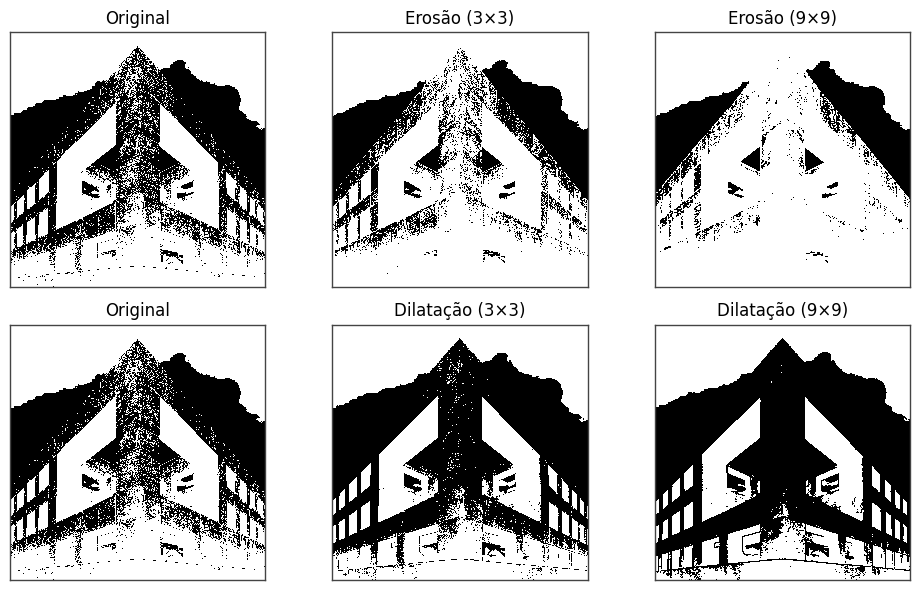

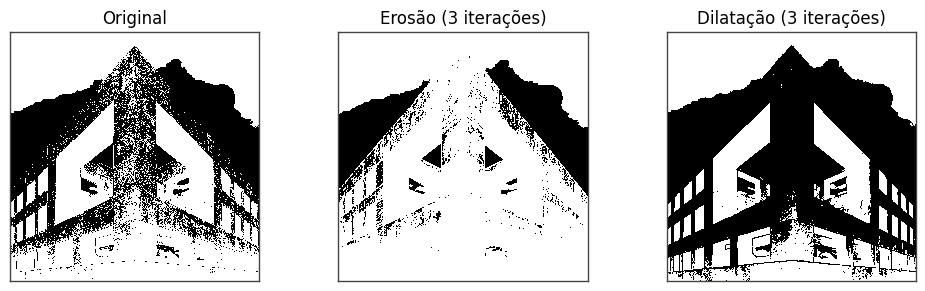

In [3]:
imageIn = img_building
img_bin = binarize_manual(imageIn, 128).astype(np.uint8) * 255

kern_small = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
kern_large = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))

er_small = cv2.erode(img_bin, kern_small, iterations=1)
er_large = cv2.erode(img_bin, kern_large, iterations=1)
di_small = cv2.dilate(img_bin, kern_small, iterations=1)
di_large = cv2.dilate(img_bin, kern_large, iterations=1)

er_iters = cv2.erode(img_bin, kern_small, iterations=3)
di_iters = cv2.dilate(img_bin, kern_small, iterations=3)

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
titles = [
    'Original', 'Erosão (3×3)', 'Erosão (9×9)',
    'Original', 'Dilatação (3×3)', 'Dilatação (9×9)'
]
images = [
    img_bin, er_small, er_large,
    img_bin, di_small, di_large
]
for ax, img, title in zip(axes.ravel(), images, titles):
    ax.imshow(img, cmap='gray_r', vmin=0, vmax=255, interpolation='nearest')
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')
        spine.set_linewidth(1)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
titles = ['Original', 'Erosão (3 iterações)', 'Dilatação (3 iterações)']
images = [img_bin, er_iters, di_iters]
for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray_r', vmin=0, vmax=255, interpolation='nearest')
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')
        spine.set_linewidth(1)
plt.tight_layout()
plt.show()

## 4.3.4. Abertura e Fecho

Esta célula introduz duas operações compostas fundamentais da **morfologia matemática**:  
a **abertura** (*opening*) e o **fecho** (*closing*).  
Ambas derivam da combinação sequencial das operações básicas (erosão e dilatação) e são aplicadas aqui a uma imagem binarizada de texto, permitindo observar o seu impacto na legibilidade e estrutura das letras.

**Descrição sequencial do código**  
1) A imagem (`img_text`) é convertida para binária com `binarize_manual(imageIn, 128)` e escalada para o intervalo [0, 255].  
2) São definidos dois **elementos estruturantes elípticos**:
   - `kern_small`: 5×5 (estrutura pequena, afeta detalhes finos);
   - `kern_large`: 9×9 (estrutura maior, com efeito mais agressivo e suavizado).  
   Ambos criados com `cv2.getStructuringElement(cv2.MORPH_ELLIPSE, …)`.  
3) Aplicam-se as operações compostas com `cv2.morphologyEx`:
   - **Abertura** (`cv2.MORPH_OPEN`) = erosão → dilatação.  
     Remove ruído e pequenos elementos isolados, preservando o formato geral das letras.  
   - **Fecho** (`cv2.MORPH_CLOSE`) = dilatação → erosão.  
     Preenche pequenas lacunas e espaços dentro dos caracteres.  
   Cada uma é testada com kernels de tamanhos 5×5 e 9×9.  
4) As imagens resultantes são organizadas num **painel 2×3**:
   - Primeira linha: *Abertura* (comparando kernel pequeno e grande);
   - Segunda linha: *Fecho* (idem).  
   Os eixos são ocultados e o colormap invertido (`gray_r`) mantém a consistência visual com as células anteriores.

**Interpretação e observações**  
- A **abertura** atua como um **filtro de suavização morfológica**: elimina pequenas manchas e saliências nas bordas das letras, útil para limpar ruído de fundo ou manchas de digitalização.  
  - Com o kernel 5×5, a imagem mantém boa legibilidade;  
  - Com 9×9, observa-se perda de traços finos e redução excessiva de detalhes.  
- O **fecho**, por contraste, **liga e consolida regiões**: preenche buracos em caracteres (“o”, “a”, “e”) e funde fragmentos próximos, útil para reforçar a continuidade de texto degradado.  
  - Com kernel maior, há risco de colagem entre caracteres adjacentes.  

Em termos conceituais:
- A **abertura** preserva o fundo (remove objetos pequenos no primeiro plano).  
- O **fecho** preserva o primeiro plano (remove buracos e ruído no fundo).  

Esta célula demonstra, portanto, que a morfologia não serve apenas para realçar contornos, mas também como **ferramenta de limpeza e regularização estrutural**, crucial em tarefas de pré-processamento de texto, segmentação de documentos e reconhecimento ótico de caracteres (OCR).

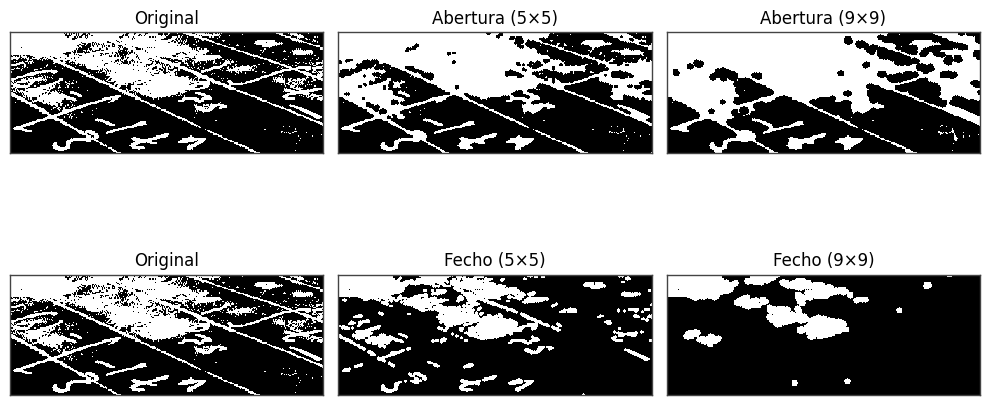

In [4]:
imageIn = img_text
img_bin = binarize_manual(imageIn, 128).astype(np.uint8) * 255

kern_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
kern_large = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))

opened_small = cv2.morphologyEx(img_bin, cv2.MORPH_OPEN, kern_small, iterations=1)
opened_large = cv2.morphologyEx(img_bin, cv2.MORPH_OPEN, kern_large, iterations=1)
closed_small = cv2.morphologyEx(img_bin, cv2.MORPH_CLOSE, kern_small, iterations=1)
closed_large = cv2.morphologyEx(img_bin, cv2.MORPH_CLOSE, kern_large, iterations=1)

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
titles = [
    'Original', 'Abertura (5×5)', 'Abertura (9×9)',
    'Original', 'Fecho (5×5)', 'Fecho (9×9)'
]
images = [
    img_bin, opened_small, opened_large,
    img_bin, closed_small, closed_large
]
for ax, img, title in zip(axes.ravel(), images, titles):
    ax.imshow(img, cmap='gray_r', vmin=0, vmax=255, interpolation='nearest')
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')
        spine.set_linewidth(1)
plt.tight_layout()
plt.show()

## 4.3.5. Implementar gradiente morfológico manual

Esta célula apresenta três transformações morfológicas derivadas — **gradiente morfológico**, **top-hat** e **black-hat** — comparando as suas implementações manuais com as funções equivalentes do **OpenCV**.  
Estas operações são variações compostas das transformações básicas (erosão e dilatação), concebidas para realçar **bordas**, **realces locais** e **sombras estruturais** numa imagem binária ou em tons de cinzento.

**Descrição sequencial do código**  
1) A imagem das moedas (`img_coins`) é convertida para binária com `binarize_manual(imageIn, 128)` e normalizada para o intervalo [0, 1].  
2) São criados dois elementos estruturantes quadrados:
   - `se_small`: 5×5, usado para o gradiente morfológico;  
   - `se_large`: 9×9, usado nas operações *top-hat* e *black-hat*.  
3) **Gradiente morfológico:**  
   - Implementação manual com `morph_gradient_manual(img_bin, se_small)` — diferença entre a dilatação e a erosão da imagem, destacando as **bordas** dos objetos.  
   - Versão OpenCV com `cv2.morphologyEx(img_bin × 255, cv2.MORPH_GRADIENT, kernel3)`.  
4) **Top-hat:**  
   - Implementação manual (`top_hat_manual`) e OpenCV (`cv2.MORPH_TOPHAT`).  
   - Calcula a diferença entre a imagem original e a sua abertura: realça **regiões claras menores** do que o elemento estruturante (pequenos brilhos).  
5) **Black-hat:**  
   - Implementação manual (`black_hat_manual`) e OpenCV (`cv2.MORPH_BLACKHAT`).  
   - Calcula a diferença entre o fecho e a imagem original: realça **regiões escuras pequenas**, como sombras ou cavidades.  
6) Os resultados são organizados em **três linhas e duas colunas**:
   - Linha 1: Gradiente (manual vs OpenCV);  
   - Linha 2: Top-hat (manual vs OpenCV);  
   - Linha 3: Black-hat (manual vs OpenCV).  
   Cada subplot é apresentado em tons invertidos (`gray_r`) e estilizado de forma consistente com os anteriores.

**Interpretação e observações**  
- O **gradiente morfológico** atua como uma **detecção de contornos morfológica**, destacando bordas externas e internas sem recorrer a derivadas.  
  - É útil para separar objetos em imagens com contraste moderado, como as moedas nesta célula.  
- O **top-hat** evidencia **pormenores brilhantes** sobre um fundo mais escuro, sendo muito usado para compensar iluminação desigual em imagens de documentos, células microscópicas ou metal polido.  
- O **black-hat**, inversamente, destaca **pormenores escuros** sobre fundo claro, revelando sombras ou sulcos.  

Na comparação entre versões **manuais** e **cv2**, nota-se a coincidência nos resultados — confirmando a correção das implementações manuais — mas também uma **diferença substancial de desempenho**, com as funções OpenCV a serem otimizadas para execução vetorizada.

Estas três operações completam o conjunto básico da morfologia aplicada à análise de forma e textura, permitindo **realce seletivo de estruturas locais** e servindo frequentemente como **etapas de pré-processamento** em tarefas de segmentação, reconhecimento e extração de padrões.

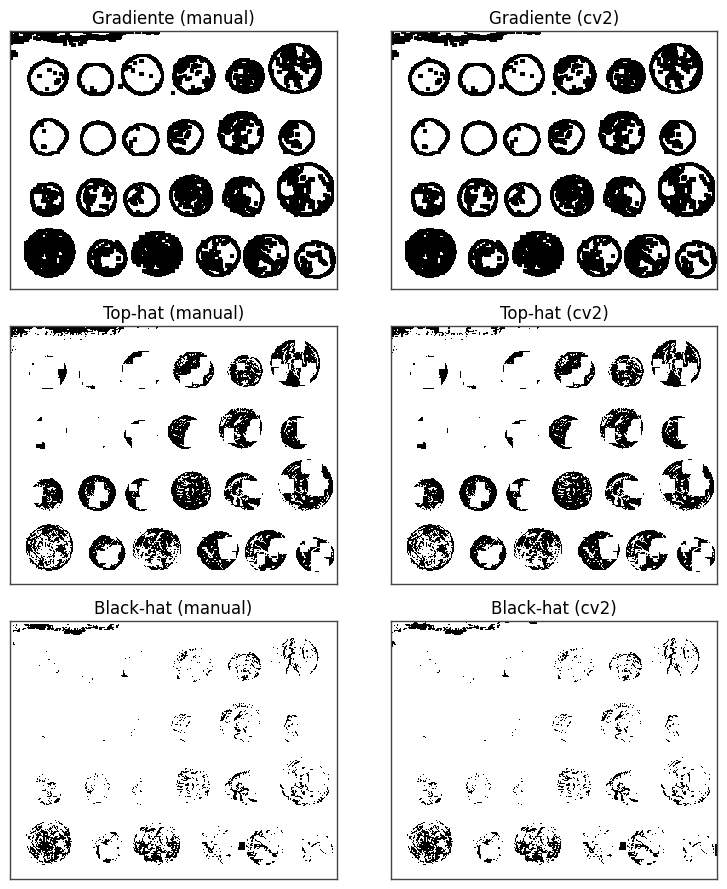

In [5]:
def opening_manual(img, selem): 
    return dilate_manual(erode_manual(img, selem), selem) 

def closing_manual(img, selem): 
    return erode_manual(dilate_manual(img, selem), selem)

def morph_gradient_manual(img, selem): 
    dil = dilate_manual(img, selem) 
    ero = erode_manual(img, selem) 
    return dil.astype(np.uint8) - ero.astype(np.uint8)

def top_hat_manual(img, selem): 
    opened = opening_manual(img, selem) 
    return img - opened 

def black_hat_manual(img, selem): 
    closed = closing_manual(img, selem) 
    return closed - img

imageIn = img_coins
img_bin = binarize_manual(imageIn, 128).astype(np.uint8)

se_small = struct_element('square', 5)
se_large = struct_element('square', 9)

grad_manual = morph_gradient_manual(img_bin, se_small)
kernel3 = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
grad_cv = cv2.morphologyEx(img_bin * 255, cv2.MORPH_GRADIENT, kernel3)

tophat_manual = top_hat_manual(img_bin, se_large)
blackhat_manual = black_hat_manual(img_bin, se_large)

kernel9 = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
tophat_cv = cv2.morphologyEx(img_bin * 255, cv2.MORPH_TOPHAT, kernel9)
blackhat_cv = cv2.morphologyEx(img_bin * 255, cv2.MORPH_BLACKHAT, kernel9)

fig, axes = plt.subplots(3, 2, figsize=(8, 9))
titles = [
    'Gradiente (manual)', 'Gradiente (cv2)',
    'Top-hat (manual)', 'Top-hat (cv2)',
    'Black-hat (manual)', 'Black-hat (cv2)'
]
images = [
    grad_manual * 255, grad_cv,
    tophat_manual * 255, tophat_cv,
    blackhat_manual * 255, blackhat_cv
]
for ax, img, title in zip(axes.ravel(), images, titles):
    ax.imshow(img, cmap='gray_r', vmin=0, vmax=255, interpolation='nearest')
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')
        spine.set_linewidth(1)
plt.tight_layout()
plt.show()

## 4.3.6. Operações em tons de cinza

Esta célula demonstra que as **operações morfológicas** — tradicionalmente aplicadas a imagens binárias — podem ser **estendidas ao domínio em tons de cinzento**, permitindo manipular diretamente **intensidades locais** de forma contínua.  
São apresentadas as versões em `scipy.ndimage` das operações básicas (erosão, dilatação, abertura e fecho), seguidas de uma comparação entre o **gradiente morfológico** em `scipy` e em `cv2`.

**Descrição sequencial do código**  
1) Cria-se uma **imagem sintética contínua** (`img_gray`) baseada na soma de duas ondas senoidais (`sin(Xg)` e `sin(Yg)`), com ruído gaussiano adicionado.  
   - A imagem é normalizada para o intervalo [0, 1] e convertida para `float32`.  
   - Este padrão senoidal fornece uma boa demonstração do comportamento das operações morfológicas sobre **variações suaves** de intensidade.  
2) Aplicam-se os operadores básicos de **morfologia cinzenta**, utilizando funções da biblioteca `scipy.ndimage`:  
   - `minimum_filter(img, size=3)` → **Erosão** (substitui cada píxel pelo menor valor na vizinhança);  
   - `maximum_filter(img, size=3)` → **Dilatação** (substitui cada píxel pelo maior valor na vizinhança).  
   - A partir deles obtêm-se:
     - **Abertura:** dilatação da imagem erodida → remove picos pequenos (*noise peaks*);  
     - **Fecho:** erosão da imagem dilatada → preenche vales e suaviza depressões.  
   - Estas operações atuam como **filtros não lineares** de suavização, preservando estruturas geométricas.  
3) Os resultados são mostrados num **painel 2×3**:  
   - Linha superior: imagem original, erosão e dilatação;  
   - Linha inferior: imagem original, abertura e fecho.  
   O colormap `gray_r` (invertido) é mantido por coerência visual com as células anteriores.  
4) Numa segunda parte, aplica-se o mesmo raciocínio a uma **imagem real** (`img_coins`), comparando:
   - O **gradiente morfológico** calculado com `scipy` (`dil - ero`) — diferença entre a dilatação e a erosão, normalizada em [0, 1];  
   - O gradiente equivalente de **OpenCV** (`cv2.morphologyEx(img, cv2.MORPH_GRADIENT, kernel)`).  
   Os resultados são exibidos lado a lado para verificar a correspondência entre bibliotecas.

**Interpretação e observações**  
- Em imagens em tons de cinzento, as operações morfológicas não alteram apenas formas binárias, mas **reconfiguram o relevo de intensidades**:
  - A **erosão** comprime picos e reduz brilho local;  
  - A **dilatação** expande regiões claras e eleva depressões;  
  - A **abertura** elimina pequenas estruturas brilhantes;  
  - O **fecho** suaviza zonas escuras e preenche pequenas lacunas.  
- O **gradiente morfológico** destaca **transições locais de intensidade** (bordas suaves), sendo uma alternativa robusta à derivada clássica — menos sensível a ruído e a variações tonais.  
- A comparação entre `scipy` e `cv2` confirma que, apesar de diferentes implementações, as operações são **conceitualmente equivalentes** e produzem resultados semelhantes quando o tamanho do kernel é idêntico.

Esta célula encerra o módulo sobre morfologia, estendendo o seu alcance do domínio binário ao **domínio contínuo**, o que é essencial em pipelines modernos de pré-processamento e extração de características.

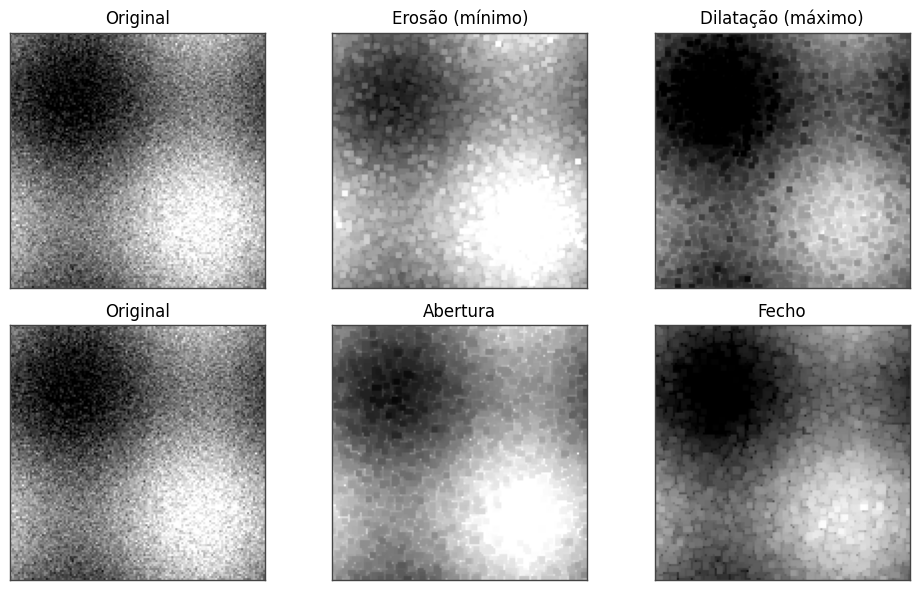

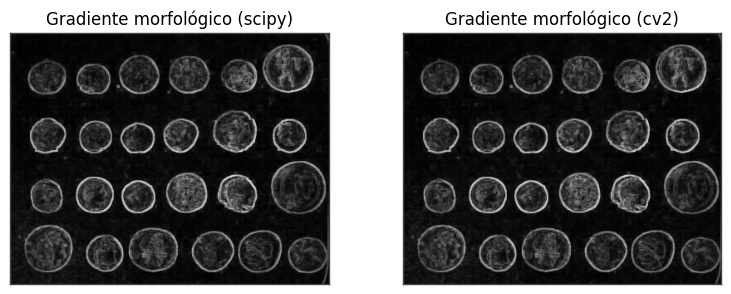

In [6]:
g_size = 128
x = np.linspace(0, 2 * np.pi, g_size)
Xg, Yg = np.meshgrid(x, x)
img_gray = np.sin(Xg) + np.sin(Yg)
img_gray = (img_gray - img_gray.min()) / (img_gray.max() - img_gray.min())
img_gray += 0.1 * np.random.randn(g_size, g_size)
img_gray = np.clip(img_gray, 0, 1).astype(np.float32)

er_gray = scipy.ndimage.minimum_filter(img_gray, size=3)
di_gray = scipy.ndimage.maximum_filter(img_gray, size=3)
open_gray = scipy.ndimage.maximum_filter(er_gray, size=3)
close_gray = scipy.ndimage.minimum_filter(di_gray, size=3)

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
titles = [
    'Original', 'Erosão (mínimo)', 'Dilatação (máximo)',
    'Original', 'Abertura', 'Fecho'
]
images = [
    img_gray, er_gray, di_gray,
    img_gray, open_gray, close_gray
]
for ax, img, title in zip(axes.ravel(), images, titles):
    ax.imshow(img, cmap='gray_r', vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')
        spine.set_linewidth(1)
plt.tight_layout()
plt.show()

img_real = img_coins.astype(np.float32) / 255.0
dil = scipy.ndimage.maximum_filter(img_real, size=3)
ero = scipy.ndimage.minimum_filter(img_real, size=3)
grad = dil - ero
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
grad_cv = cv2.morphologyEx(img_coins, cv2.MORPH_GRADIENT, kernel)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
titles = ['Gradiente morfológico (scipy)', 'Gradiente morfológico (cv2)']
images = [grad, grad_cv]
for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1 if img.dtype!=np.uint8 else 255)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')
        spine.set_linewidth(1)
plt.tight_layout()
plt.show()

## 4.3.7. Operações morfológicas em imagens a cores

Esta secção demonstra como as **operações morfológicas** podem ser aplicadas seletivamente sobre **canais individuais de uma imagem em HSV**, permitindo manipular **luminosidade, saturação e matiz** de modo independente.  
O exemplo divide-se em duas células complementares: a primeira atua apenas sobre o canal **V (Value)**, e a segunda estende o princípio aos três canais (**H, S, V**) de forma comparativa.

**Descrição sequencial do código**  
1) A imagem RGB (`img_man`) é convertida para o espaço **HSV** com `cv2.cvtColor(img_color, cv2.COLOR_RGB2HSV)`.  
   - Este espaço desacopla **matiz (H)**, **saturação (S)** e **valor/luminosidade (V)**, permitindo controlar separadamente cada componente perceptual.  

2) **Primeira célula – Modificação do canal V (Value):**
   - O canal **V** é extraído e processado morfologicamente com um elemento estruturante retangular de 9×9 píxeis (`cv2.MORPH_RECT`).  
   - **Erosão:** `cv2.erode(V_channel, kernel)` → reduz o brilho, escurecendo áreas claras e acentuando sombras.  
   - **Dilatação:** `cv2.dilate(V_channel, kernel)` → aumenta o brilho, expandindo zonas luminosas.  
   - Após o processamento, as versões alteradas de **V** são reinseridas nas cópias do modelo HSV, preservando os canais **H** e **S** originais.  
   - Por fim, converte-se de volta a RGB para exibir:  
     - Imagem original;  
     - Erosão no canal V (mais escura);  
     - Dilatação no canal V (mais clara).  
   - A comparação direta evidencia o impacto da morfologia sobre o brilho, sem alteração de cor.

3) **Segunda célula – Dilatação separada dos canais H, S e V:**  
   - Define-se um elemento estruturante **elíptico de 9×9** para dilatar cada canal de forma independente:  
     - `H_dil`: dilatação do canal de **matiz (H)** — pode deslocar ligeiramente as tonalidades dominantes;  
     - `S_dil`: dilatação do canal de **saturação (S)** — intensifica a vivacidade das cores;  
     - `V_dil`: dilatação do canal de **luminosidade (V)** — clareia a imagem, semelhante ao exemplo anterior.  
   - Para cada canal, o resultado é reinserido numa cópia da imagem HSV e reconvertido para RGB.  
   - O painel de quatro colunas exibe:  
     - Imagem original;  
     - Dilatação sobre **H**;  
     - Dilatação sobre **S**;  
     - Dilatação sobre **V**.

**Interpretação e observações**  
- A **morfologia no espaço HSV** oferece um controlo seletivo e intuitivo da aparência cromática:  
  - No **canal H**, as operações podem causar **variações tonais locais**, visíveis em transições de cor ou áreas mistas;  
  - No **canal S**, a **dilatação** tende a **saturar as cores**, tornando-as mais intensas e contrastadas, enquanto uma **erosão** (não mostrada aqui) produziria o efeito oposto, dessaturando;  
  - No **canal V**, as operações equivalem a manipulações de **brilho e contraste** de forma espacialmente dependente.  
- A escolha do **elemento estruturante** (forma e tamanho) define a escala espacial da transformação:  
  um kernel maior atua sobre áreas mais amplas, suavizando gradientes de cor e brilho.  
- Comparar os três canais tratados independentemente permite observar como **a morfologia pode alterar atributos perceptuais distintos** sem misturar informação entre cor e luminância.

Em síntese, estas duas células demonstram que as operações morfológicas podem ser aplicadas **além da segmentação e do domínio binário**, servindo também como **ferramenta criativa e analítica** para o **controlo local de cor, saturação e iluminação** em imagens RGB convertidas para HSV.

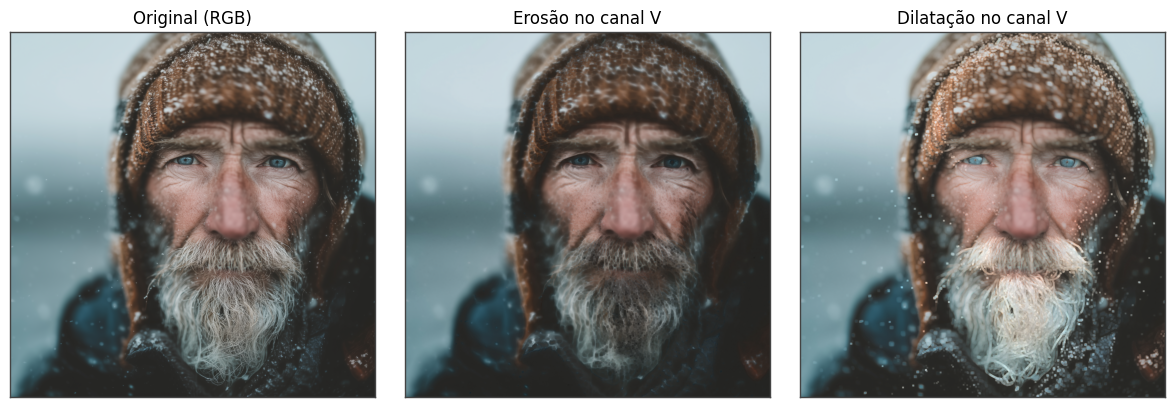

In [7]:
img_color = img_man

hsv = cv2.cvtColor(img_color, cv2.COLOR_RGB2HSV)
V_channel = hsv[:, :, 2].copy()

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9))
V_eroded = cv2.erode(V_channel, kernel, iterations=1)
V_dilated = cv2.dilate(V_channel, kernel, iterations=1)

hsv_eroded = hsv.copy()
hsv_dilated = hsv.copy()
hsv_eroded[:, :, 2] = V_eroded
hsv_dilated[:, :, 2] = V_dilated

img_eroded = cv2.cvtColor(hsv_eroded, cv2.COLOR_HSV2RGB)
img_dilated = cv2.cvtColor(hsv_dilated, cv2.COLOR_HSV2RGB)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
titles = ['Original (RGB)', 'Erosão no canal V', 'Dilatação no canal V']
images = [img_color, img_eroded, img_dilated]
for ax, img, title in zip(axes, images, titles):
    ax.imshow(img)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')
        spine.set_linewidth(1)
plt.tight_layout()
plt.show()

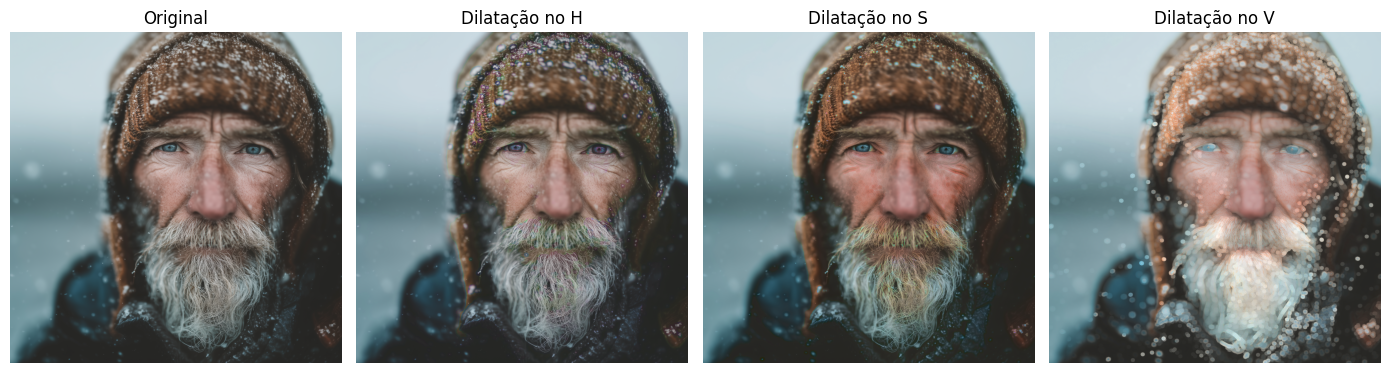

In [8]:
img = img_man
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))

H_dil = cv2.dilate(hsv[:, :, 0], kernel, iterations=3)
S_dil = cv2.dilate(hsv[:, :, 1], kernel, iterations=3)
V_dil = cv2.dilate(hsv[:, :, 2], kernel, iterations=3)

hsv_H, hsv_S, hsv_V = hsv.copy(), hsv.copy(), hsv.copy()
hsv_H[:, :, 0] = H_dil
hsv_S[:, :, 1] = S_dil
hsv_V[:, :, 2] = V_dil

imgs = [
    img,
    cv2.cvtColor(hsv_H, cv2.COLOR_HSV2RGB),
    cv2.cvtColor(hsv_S, cv2.COLOR_HSV2RGB),
    cv2.cvtColor(hsv_V, cv2.COLOR_HSV2RGB)
]
titles = ['Original', 'Dilatação no H', 'Dilatação no S', 'Dilatação no V']

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, im, title in zip(axes, imgs, titles):
    ax.imshow(im)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4.3.8. Componentes conexas e labeling

Esta célula apresenta um exemplo completo de **rotulagem e análise de componentes conexas** em imagens binárias, usando o módulo `skimage.measure`.  
A operação identifica e mede objetos distintos (neste caso, **células**), aplicando **morfologia de limpeza**, **filtragem por área mínima** e **visualização sobreposta com bounding boxes**.

**Descrição sequencial do código**  
1) A imagem de entrada (`img_cells`) é binarizada com `binarize_manual(img_cells, 100)`.  
   - Os valores são convertidos para `uint8` para compatibilidade com as operações de OpenCV.  
2) Aplica-se uma **abertura morfológica** (`cv2.morphologyEx(..., cv2.MORPH_OPEN)`) com um elemento estruturante elíptico 3×3.  
   - Esta operação remove **ruído isolado** e pequenas partículas desconectadas, preservando as formas principais.  
3) A imagem resultante é **rotulada** com `measure.label(img_bin_clean, connectivity=2)`, que atribui um identificador numérico a cada grupo conexo de píxeis.  
   - A conectividade 2D considera 8 vizinhos (diagonais incluídas).  
4) São calculadas as propriedades de cada componente através de `measure.regionprops(labels_sk)`.  
   - Cada objeto possui atributos como **área**, **centroide** e **bounding box**.  
5) Define-se um **limiar de área mínima** (`min_area = 2000`) para eliminar ruído residual e pequenas estruturas.  
   - As etiquetas que satisfazem esta condição são mantidas no array `filtered_labels`.  
   - As regiões válidas são armazenadas na lista `regions`.  
   - Calcula-se também o número total de objetos (`num_components`) e a **área média**.  
6) Cria-se uma **imagem colorida de sobreposição** (`color.label2rgb`) que pinta cada região identificada com uma cor distinta sobre o fundo preto.  
7) No gráfico principal:
   - São desenhadas as regiões coloridas;  
   - Para cada região, é marcado o **centroide** (ponto branco);  
   - É desenhado um **retângulo delimitador** (bounding box) em branco com um efeito de contorno preto (`matplotlib.patheffects`) para maior legibilidade.  
   - O título do gráfico resume os resultados: número de objetos, área média e limiar aplicado.  
   - O eixo é removido para foco na visualização.

**Interpretação e observações**  
- O processo ilustra um **fluxo típico de segmentação pós-binarização**, em que cada objeto identificado é analisado individualmente.  
- O **limiar de área mínima** atua como filtro morfológico de escala, descartando falsos positivos.  
- As **bounding boxes** permitem quantificar e isolar cada célula, enquanto os **centroides** facilitam análises espaciais (ex.: distribuição ou densidade).  
- O uso de `color.label2rgb` fornece uma **visualização intuitiva** das regiões segmentadas, crucial para validar resultados de segmentação automática.  
- A métrica de **área média** pode ser utilizada para comparar diferentes técnicas de segmentação ou para inferir propriedades físicas (ex.: tamanho médio de partículas, células ou objetos industriais).

Em síntese, esta célula exemplifica a etapa final de uma pipeline de morfologia e segmentação: **identificação, filtragem e caracterização de objetos**, transformando a imagem binária num conjunto de **entidades mensuráveis**.

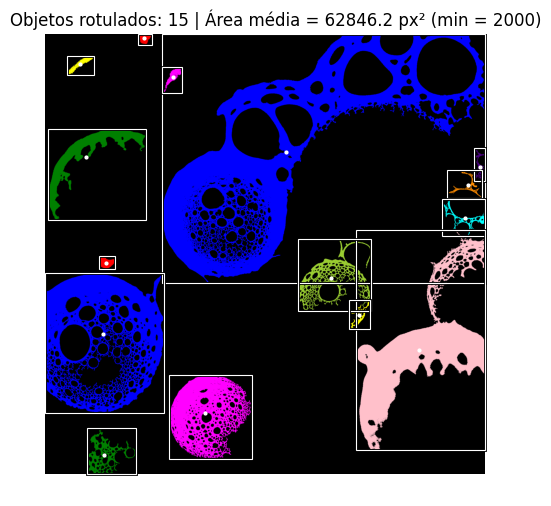

In [9]:
from matplotlib import patheffects

img_bin = binarize_manual(img_cells, 100).astype(np.uint8)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
img_bin_clean = cv2.morphologyEx(img_bin, cv2.MORPH_OPEN, kernel)

labels_sk = measure.label(img_bin_clean, connectivity=2)
regions = measure.regionprops(labels_sk)

min_area = 2000
filtered_labels = np.zeros_like(labels_sk)
for r in regions:
    if r.area >= min_area:
        filtered_labels[labels_sk == r.label] = r.label

regions = [r for r in regions if r.area >= min_area]
num_components = len(regions)
mean_area = np.mean([r.area for r in regions]) if regions else 0

img_color = color.label2rgb(filtered_labels, bg_label=0, bg_color=(0, 0, 0), kind='overlay')

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img_color)
for r in regions:
    y, x = r.centroid
    minr, minc, maxr, maxc = r.bbox
    ax.plot(x, y, 'w.', markersize=4)
    rect = plt.Rectangle((minc, minr), maxc - minc, maxr - minr,
                         fill=False, edgecolor='white', linewidth=0.8)
    rect.set_path_effects([patheffects.withStroke(linewidth=2, foreground='black')])
    ax.add_patch(rect)
ax.set_title(f'Objetos rotulados: {num_components} | Área média = {mean_area:.1f} px² (min = {min_area})')
ax.axis('off')
plt.show()

## 4.3.9. Esqueletização e Thinning

Esta célula apresenta duas operações morfológicas de alto nível aplicadas a uma imagem de **texto binarizado**:  
o **gradiente morfológico** (para detetar contornos) e a **esqueletização** (para reduzir as formas ao seu traçado estrutural).  
Ambas são visualizadas individualmente e combinadas numa sobreposição a cores para comparação direta.

**Descrição sequencial do código**  
1) A imagem de texto (`data.text()`) é carregada a partir dos exemplos do `skimage`.  
   - É uma imagem de teste com caracteres pretos sobre fundo branco.  
2) Calcula-se o **limiar ótimo de Otsu** (`threshold_otsu`) e binariza-se a imagem com `(img_text > th)`.  
   - O resultado é uma matriz binária `img_text_bin` onde o texto é representado por 1s (branco) e o fundo por 0s (preto).  
3) Aplica-se o **gradiente morfológico** com `morph_gradient_manual(img_text_bin, struct_element('square', 3))`.  
   - O gradiente é obtido pela diferença entre a dilatação e a erosão, destacando **as bordas externas e internas das letras**.  
4) Em paralelo, calcula-se o **esqueleto morfológico** com `morphology.skeletonize(img_text_bin.astype(bool))`.  
   - Esta operação reduz cada caractere à sua **linha mediana**, mantendo a conectividade topológica.  
   - O resultado é uma versão minimalista da forma do texto, ideal para análises estruturais (ex.: espessura, curvatura, conectividade).  
5) É criado um **overlay RGB** para visualização combinada:
   - O canal vermelho representa o **contorno** (gradiente morfológico).  
   - O canal verde representa o **esqueleto**.  
   - As zonas sobrepostas (onde ambos coincidem) aparecem em amarelo.  
6) Quatro imagens são exibidas lado a lado:
   - Texto binário original;  
   - Contorno (preto e branco);  
   - Esqueleto (preto e branco);  
   - Sobreposição colorida (vermelho = contorno, verde = esqueleto).  

**Interpretação e observações**  
- O **gradiente morfológico** evidencia as **bordas visuais** das letras, enquanto o **esqueleto** revela a sua **estrutura geométrica essencial**.  
- Na prática, as duas técnicas são complementares:
  - O gradiente é útil para **detetar limites e espessura** das formas;  
  - O esqueleto é útil para **análises topológicas e reconhecimento de padrões**, por exemplo em OCR ou vetorização de traços.  
- A **sobreposição colorida** ilustra claramente como o esqueleto se mantém **centrado dentro das bordas** detectadas, validando a coerência das transformações.  
- Estas operações são sensíveis ao **ruído** e à **espessura dos traços**: pequenas variações na binarização podem alterar a continuidade do esqueleto ou gerar contornos duplicados.

Em síntese, esta célula mostra como as transformações morfológicas podem ir além da segmentação, servindo para **análise estrutural** de formas — neste caso, reduzindo o texto a duas representações fundamentais: **os limites** e **a espinha dorsal**.

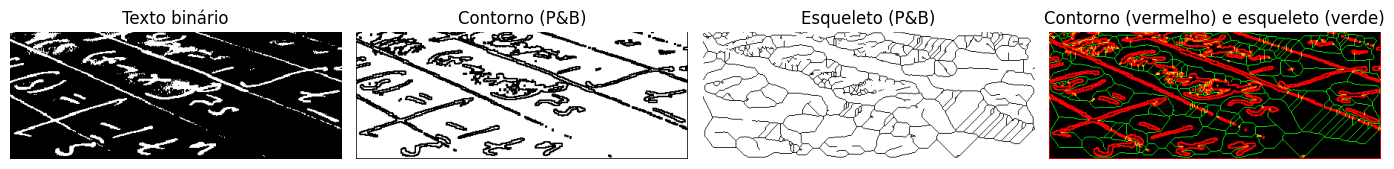

In [10]:
img_text = data.text()
th = threshold_otsu(img_text)
img_text_bin = (img_text > th).astype(np.uint8)

outline_text = morph_gradient_manual(img_text_bin, struct_element('square', 3))
skeleton_text = morphology.skeletonize(img_text_bin.astype(bool)).astype(np.uint8)

overlay = np.zeros((*outline_text.shape, 3), dtype=np.uint8)
overlay[..., 0] = outline_text * 255
overlay[..., 1] = skeleton_text * 255

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
titles = [
    'Texto binário',
    'Contorno (P&B)',
    'Esqueleto (P&B)',
    'Contorno (vermelho) e esqueleto (verde)'
]
images = [img_text_bin, outline_text, skeleton_text, overlay]

for ax, img, title in zip(axes, images, titles):
    if img.ndim == 2:
        ax.imshow(img, cmap='gray_r', vmin=0, vmax=1)
    else:
        ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')
        spine.set_linewidth(1)
plt.tight_layout()
plt.show()

## 4.3.10. Reconstrução Morfológica

Esta célula ilustra o conceito de **reconstrução morfológica por dilatação condicionada**, uma técnica poderosa para restaurar regiões de interesse a partir de uma **semente inicial (seed)** limitada por uma **máscara (mask)**.  
O exemplo utiliza duas formas circulares para demonstrar como apenas a região conectada à semente é reconstruída, respeitando as restrições impostas pela máscara.

**Descrição sequencial do código**  
1) Define-se uma imagem binária de tamanho 128×128 com duas regiões circulares:  
   - Uma centrada em (40, 40) e outra em (90, 90), ambas com raio 25 px.  
   - Esta matriz constitui a **máscara (`mask`)**, representando o domínio permitido para a reconstrução.  
2) Cria-se uma **imagem de semente (`seed`)** com um círculo menor (raio = 10 px) contido apenas dentro da bolha superior-esquerda.  
   - Esta região inicial é o ponto de partida da reconstrução.  
3) A função `reconstruction(seed, mask)` implementa o processo iterativo:
   - Em cada iteração:
     - Realiza-se uma **dilatação** sobre a semente com um elemento estruturante quadrado 3×3 (`struct_element('square', 3)`);  
     - O resultado é **limitado pela máscara** através de `np.minimum(dil, mask)` — impedindo que a dilatação ultrapasse as fronteiras da máscara;  
     - O processo repete-se até estabilizar (nenhuma alteração entre iterações).  
   - O resultado é a **região reconstruída** conectada à semente dentro da máscara.  
4) A imagem `diff` mostra as **zonas não alcançadas pela reconstrução**, obtidas por `mask - recon`.  
   - Estas correspondem à segunda bolha, isolada da semente inicial.  
5) As quatro imagens exibidas são:
   - Máscara completa (as duas bolhas);  
   - Semente (círculo pequeno dentro da bolha esquerda);  
   - Resultado da reconstrução (região da bolha esquerda totalmente recuperada);  
   - Diferença (a bolha direita, não reconstruída).

**Interpretação e observações**  
- A **reconstrução morfológica** é um processo de **propagação controlada**, no qual uma semente cresce iterativamente **até onde a máscara o permite**.  
- É frequentemente usada em:
  - **Restauração de regiões conectadas** após erosão;  
  - **Separação de objetos** com ligação fraca;  
  - **Extração de componentes específicos** em imagens com múltiplas regiões semelhantes.  
- No exemplo, a semente só existe dentro da bolha esquerda, portanto a reconstrução **não se propaga** até à bolha direita, por falta de conectividade.  
- A diferença visual (`diff`) confirma que **a reconstrução atua apenas sobre regiões conectadas** à semente, o que a distingue de operações como a dilatação simples.  

Em síntese, esta demonstração mostra de forma clara a **ideia de crescimento condicionado**, onde a **máscara define o limite** e a **semente define a origem** — um conceito fundamental em morfologia matemática, com aplicações diretas em **segmentação, restauração e filtragem seletiva de formas**.

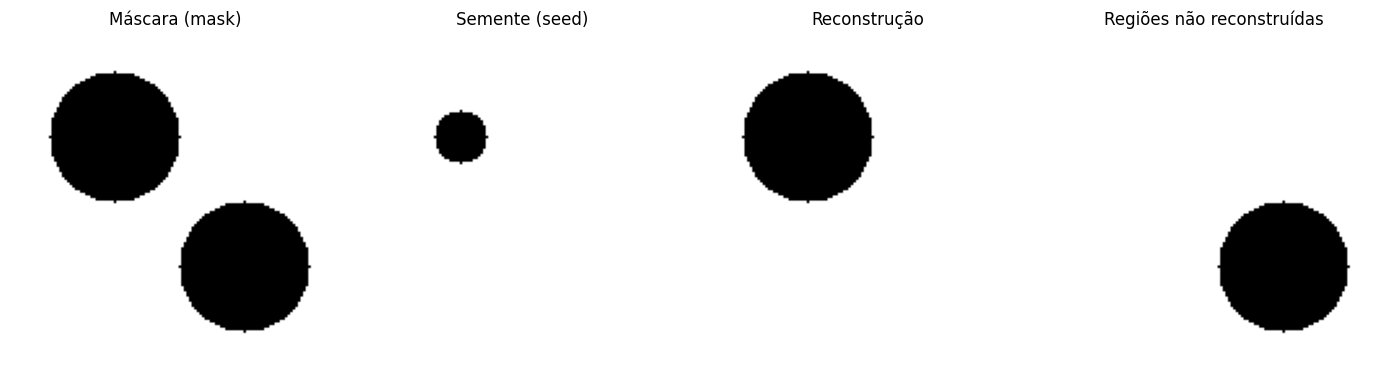

In [11]:
size = 128
X, Y = np.ogrid[:size, :size]

mask = np.zeros((size, size), dtype=np.uint8)
mask[(X - 40)**2 + (Y - 40)**2 <= 25**2] = 1
mask[(X - 90)**2 + (Y - 90)**2 <= 25**2] = 1

seed = np.zeros_like(mask)
seed[(X - 40)**2 + (Y - 40)**2 <= 10**2] = 1  # só dentro da bolha superior-esquerda

def reconstruction(seed, mask):
    selem = struct_element('square', 3)
    prev = np.zeros_like(seed)
    curr = seed.copy()
    while not np.array_equal(curr, prev):
        prev = curr.copy()
        dil = dilate_manual(curr, selem)
        curr = np.minimum(dil, mask)
    return curr

recon = reconstruction(seed, mask)
diff = np.clip(mask - recon, 0, 1)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
titles = ['Máscara (mask)', 'Semente (seed)', 'Reconstrução', 'Regiões não reconstruídas']
images = [mask, seed, recon, diff]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray_r', vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')
        spine.set_linewidth(1)
plt.tight_layout()
plt.show()

## 4.3.11. Gradientes e Segmentação via morfologia

Esta célula demonstra o uso conjunto de **morfologia matemática** e do algoritmo **watershed (divisão de bacias)** para segmentar uma figura em forma de anel em regiões conectadas, ilustrando um exemplo clássico de **segmentação baseada em gradiente e marcadores**.

**Descrição sequencial do código**  
1) O elemento estruturante é definido como um **disco de raio 5** (`struct_element('disk', 5)`), apropriado para formas circulares.  
2) Calcula-se o **gradiente morfológico** de `ring`, que realça as bordas internas e externas do anel — isto é, as zonas de transição entre o fundo e o objeto.  
   - O gradiente serve aqui como **imagem de relevo**, sobre a qual o watershed vai operar.  
3) É obtida a **transformada da distância euclidiana** (`scipy.ndimage.distance_transform_edt`), que mede a distância de cada píxel ao fundo.  
   - Os valores máximos dessa distância correspondem a potenciais **centros das regiões**.  
4) As posições dos picos locais são extraídas com `peak_local_max(distance, labels=ring, footprint=np.ones((5, 5)), num_peaks=2)`.  
   - O parâmetro `num_peaks=2` força a deteção de dois máximos principais, um para cada lóbulo do anel.  
5) Cria-se uma matriz `markers`, na qual cada máximo é rotulado com um valor inteiro distinto (1, 2, …).  
   - Estes marcadores servirão como **fontes de crescimento** para o watershed.  
6) Executa-se o **algoritmo watershed** (`watershed(grad_ring, markers, mask=ring)`), que:
   - Inunda o relevo definido pelo gradiente morfológico;  
   - Faz crescer cada região a partir dos marcadores até atingir os limites definidos pelas bordas;  
   - Gera o mapa de rótulos `labels_ws`, com cada região identificada por um número diferente.  
7) Para visualização:
   - O **contorno das regiões** é obtido via `morph_gradient_manual` aplicado ao mapa de rótulos;  
   - Constrói-se uma imagem colorida (`overlay_ws`) com:
     - Canal vermelho: máscara original (`ring`);  
     - Canal verde: regiões segmentadas (`labels_ws` moduladas em intensidade);  
     - Canal azul: contorno das divisões (`contours_ws`).  
8) São exibidas três imagens:
   - O gradiente morfológico (relevo);  
   - As regiões segmentadas (`labels_ws`) em cores distintas (`nipy_spectral`);  
   - A sobreposição colorida combinando máscara, regiões e contornos.

**Interpretação e observações**  
- O **gradiente morfológico** atua como uma superfície topográfica, e o **watershed** identifica **linhas de separação** entre as bacias (regiões de mínima intensidade).  
- O uso de **marcadores explícitos** evita o sobre-segmentar excessivo comum em versões automáticas do watershed.  
- No caso do anel, o algoritmo divide corretamente a forma em duas regiões conectadas, delimitadas pelas cristas do gradiente.  
- O resultado final (`overlay_ws`) mostra de forma clara:
  - O objeto original (vermelho);  
  - As regiões separadas (tons de verde);  
  - As fronteiras de segmentação (azul).  
- A metodologia é extensível a imagens reais — por exemplo, para **separar células sobrepostas**, **delimitar objetos adjacentes** ou **analisar componentes de textura**.

Em resumo, esta célula exemplifica o **princípio do watershed controlado por marcadores**, combinando morfologia e topologia:  
a forma do gradiente define o relevo, as sementes controlam a inundação e a máscara limita o domínio da segmentação.

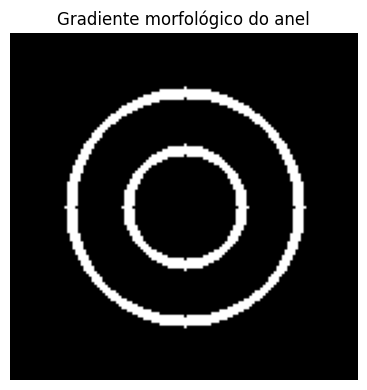

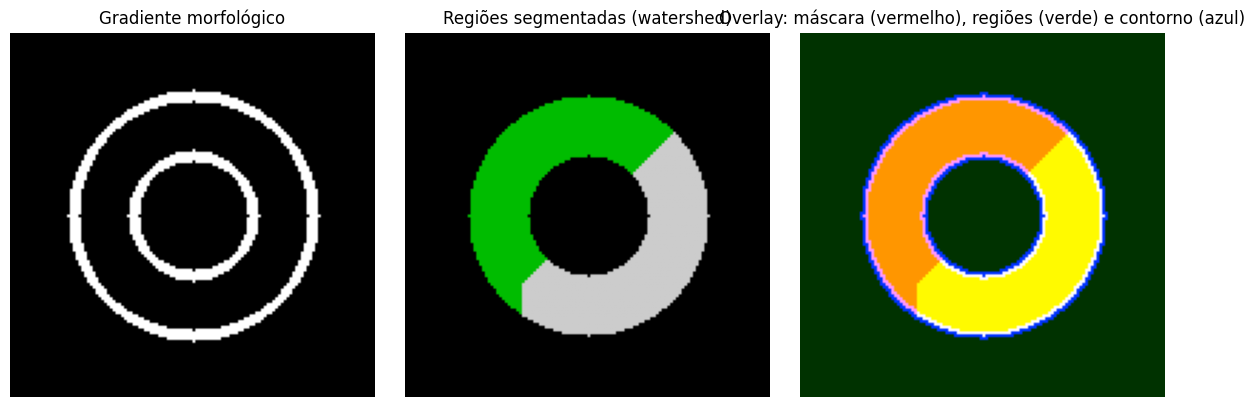

In [12]:
se = struct_element('disk', 5)
grad_ring = morph_gradient_manual(ring, se)
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(grad_ring, cmap='gray', vmin=0, vmax=1)
ax.set_title('Gradiente morfológico do anel')
ax.axis('off')
for spine in ax.spines.values():
    spine.set_edgecolor('#444')
    spine.set_linewidth(1)
plt.tight_layout()
plt.show()
from skimage.segmentation import watershed
from skimage.feature import peak_local_max

distance = scipy.ndimage.distance_transform_edt(ring)
coords = peak_local_max(distance, labels=ring, footprint=np.ones((5, 5)), num_peaks=2)
markers = np.zeros_like(ring, dtype=int)
for idx, (r0, c0) in enumerate(coords, start=1):
    markers[r0, c0] = idx

labels_ws = watershed(grad_ring.astype(float), markers, mask=ring.astype(bool))

contours_ws = morph_gradient_manual(labels_ws.astype(np.uint8) > 0, struct_element('square', 3))
overlay_ws = np.zeros((*ring.shape, 3), dtype=np.uint8)
overlay_ws[..., 1] = (labels_ws % 3) * 100 + 50
overlay_ws[..., 2] = contours_ws * 255
overlay_ws[..., 0] = ring * 255

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
titles = [
    'Gradiente morfológico',
    'Regiões segmentadas (watershed)',
    'Overlay: máscara (vermelho), regiões (verde) e contorno (azul)'
]
images = [grad_ring, labels_ws, overlay_ws]

for ax, img, title in zip(axes, images, titles):
    if img.ndim == 2:
        ax.imshow(img, cmap='nipy_spectral' if title.startswith('Regiões') else 'gray')
    else:
        ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')
        spine.set_linewidth(1)
plt.tight_layout()
plt.show()

## 4.3.12 - Operações compostas e análise

Esta célula combina **operações morfológicas sequenciais**, **análise de área/perímetro** e **métricas geométricas** para explorar o comportamento estrutural de objetos binários sob transformações morfológicas.  
O exemplo divide-se em três partes: (1) filtragem e esqueletização, (2) análise da área com o tamanho do elemento estruturante, e (3) cálculo de métricas geométricas.

**Descrição sequencial do código**  
1) Cria-se uma **imagem binária aleatória** de 64×64, com aproximadamente 70% de píxeis brancos (`img_noise`).  
   - Esta imagem simula ruído binário disperso, útil para testar a capacidade de filtragem morfológica.  
2) Define-se um elemento estruturante quadrado 3×3 (`struct_element('square', 3)`) e aplicam-se operações clássicas:  
   - **Abertura (`opening_manual`)**: remove ruído e pequenas protuberâncias;  
   - **Fecho (`closing_manual`)**: preenche pequenos buracos ou interrupções após a abertura;  
   - **Gradiente morfológico (`morph_gradient_manual`)**: evidencia as transições entre regiões (as bordas dos aglomerados);  
   - **Esqueleto (`morphology.skeletonize`)**: reduz as formas filtradas às suas linhas centrais, preservando a conectividade topológica.  
3) As cinco imagens — original, aberta, fechada, gradiente e esqueleto — são apresentadas lado a lado para visualização comparativa.  
   - Observa-se a **progressiva simplificação** da estrutura e a **preservação do essencial geométrico**.  

4) Na segunda parte, analisa-se a **evolução da área** com o tamanho do elemento estruturante.  
   - Para três tamanhos (3×3, 5×5, 9×9), aplicam-se abertura e fecho a uma forma geométrica (`img_square`), e mede-se a soma dos píxeis brancos.  
   - Os resultados são traçados em gráfico:  
     - A **abertura** reduz a área à medida que o elemento cresce (remoção de detalhes finos);  
     - O **fecho** tende a aumentá-la (preenchimento de lacunas).  
   - A figura resultante mostra o **efeito oposto e complementar** destas duas operações.  

5) Em seguida, define-se uma função `geometric_metrics(img)` que calcula três parâmetros fundamentais:
   - **Área**: número total de píxeis brancos (`img.sum()`);  
   - **Perímetro**: estimado pelo somatório do gradiente morfológico;  
   - **Compacidade**:  
     $$
     C = \frac{P^2}{4 \pi A}
     $$
     onde $P$ é o perímetro e $A$ a área.  
     - Para um círculo perfeito, $C = 1$; valores maiores indicam formas mais irregulares.  
   - O resultado é impresso com precisão de 3 casas decimais.  

6) Finalmente, avalia-se a **erosão progressiva** de uma figura (`img_square`) à medida que o elemento estruturante aumenta (1×1 até 15×15, passo 2).  
   - Calcula-se a **área restante** após cada erosão, mostrando como o objeto se contrai até desaparecer.  
   - O gráfico ilustra a **relação entre o tamanho do elemento e a perda de área**, evidenciando o ponto em que a estrutura colapsa completamente.

**Interpretação e observações**  
- As operações morfológicas permitem **controlar o nível de detalhe** visível numa forma, atuando como filtros espaciais baseados na geometria local.  
- O comportamento da **área e da compacidade** fornece uma caracterização quantitativa útil em:
  - **Análise de textura e forma**;  
  - **Medidas de regularidade geométrica**;  
  - **Filtragem adaptativa** e **avaliação de segmentação**.  
- O **esqueleto** mostra como a topologia é preservada mesmo após transformações intensas, reforçando o valor das técnicas morfológicas para representação estrutural.

Em síntese, esta célula integra operações de **filtragem morfológica, análise métrica e erosão progressiva**, permitindo compreender como a forma e a área se modificam sob variações estruturais controladas — uma ponte entre o processamento binário e a **morfometria digital**.

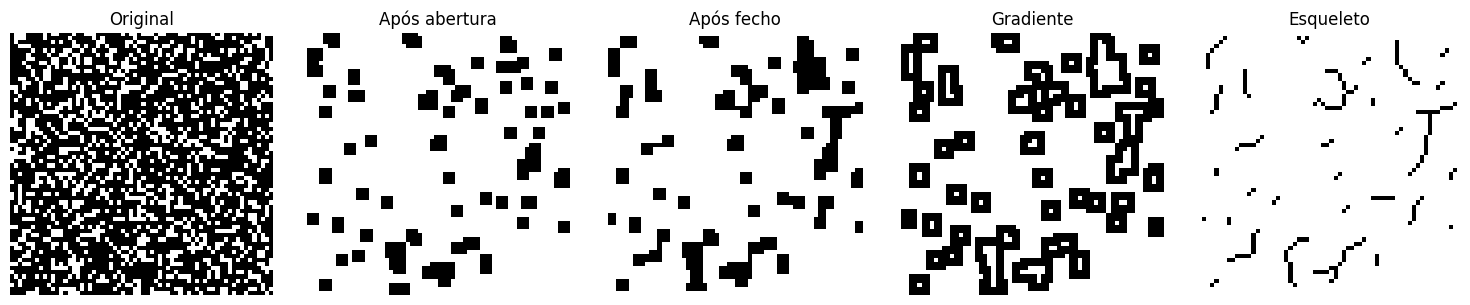

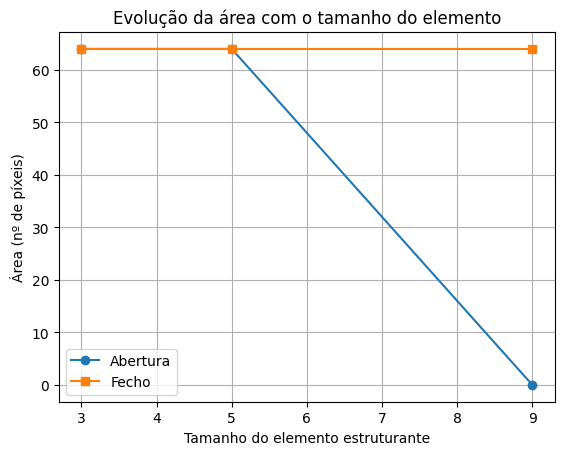

Área: 64, Perímetro: 64, Compacidade: 5.093


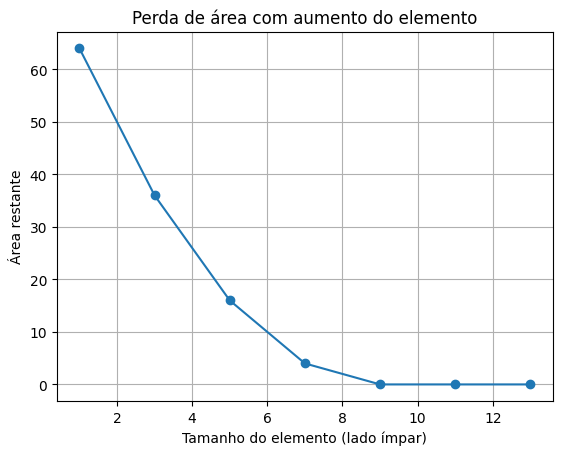

In [13]:
imageIn = img_noise

se = struct_element('square', 3)
opened = opening_manual(imageIn, se)
closed = closing_manual(opened, se)
grad = morph_gradient_manual(closed, se)
skeleton = morphology.skeletonize(closed.astype(bool)).astype(np.uint8)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
titles = ['Original', 'Após abertura', 'Após fecho', 'Gradiente', 'Esqueleto']
images = [imageIn, opened, closed, grad, skeleton]
for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray_r', vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')
        spine.set_linewidth(1)
plt.tight_layout()
plt.show()

sizes = [3, 5, 9]
areas_open = []
areas_close = []
for s in sizes:
    se = struct_element('square', s)
    img_open = opening_manual(img_square, se)
    img_close = closing_manual(img_square, se)
    areas_open.append(img_open.sum())
    areas_close.append(img_close.sum())

fig, ax = plt.subplots()
ax.plot(sizes, areas_open, marker='o', label='Abertura')
ax.plot(sizes, areas_close, marker='s', label='Fecho')
ax.set_xlabel('Tamanho do elemento estruturante')
ax.set_ylabel('Área (nº de píxeis)')
ax.legend()
ax.set_title('Evolução da área com o tamanho do elemento')
ax.grid(True)
plt.show()

def geometric_metrics(img):
    area = img.sum()
    perim = morph_gradient_manual(img, struct_element('square', 3)).sum()
    compacity = (perim ** 2) / (4 * np.pi * area + 1e-8)
    return area, perim, compacity

a, p, c = geometric_metrics(img_square)
print(f"Área: {a:.0f}, Perímetro: {p:.0f}, Compacidade: {c:.3f}")

sizes = np.arange(1, 15, 2)
areas = []
for s in sizes:
    se = struct_element('square', s)
    er = erode_manual(img_square, se)
    areas.append(er.sum())

fig, ax = plt.subplots()
ax.plot(sizes, areas, marker='o')
ax.set_xlabel('Tamanho do elemento (lado ímpar)')
ax.set_ylabel('Área restante')
ax.set_title('Perda de área com aumento do elemento')
ax.grid(True)
plt.show()

## 4.3 Funções extra

Cria um conjunto de imagens binárias padronizadas (quadrado, círculo, cruz, ruído) que podem ser reutilizadas noutros exercícios. Esta função facilita a geração rápida de dados de teste sem duplicação de código em várias células. O estudante pode adicionar novas formas conforme necessário.

In [14]:
def generate_structures(size=128):
    imgs = {}
    sq = np.zeros((size, size), dtype=np.uint8)
    sq[size//4:3*size//4, size//4:3*size//4] = 1
    imgs['square'] = sq
    circ = np.zeros_like(sq)
    X, Y = np.ogrid[:size, :size]
    mask = (X - size//2) ** 2 + (Y - size//2) ** 2 <= (size//4) ** 2
    circ[mask] = 1
    imgs['circle'] = circ
    cross = np.zeros_like(sq)
    cross[size//2 - 1:size//2 + 1, :] = 1
    cross[:, size//2 - 1:size//2 + 1] = 1
    imgs['cross'] = cross
    noise = (np.random.rand(size, size) > 0.7).astype(np.uint8)
    imgs['noise'] = noise
    return imgs

def compare_morph_ops(img, kernel_sizes):
    results = {}
    for k in kernel_sizes:
        se = struct_element('square', k)
        res = {}
        res['erode'] = erode_manual(img, se)
        res['dilate'] = dilate_manual(img, se)
        res['open'] = opening_manual(img, se)
        res['close'] = closing_manual(img, se)
        results[k] = res
    return results

def morph_profile(img, op, sizes):
    profile = []
    for s in sizes:
        se = struct_element('square', s)
        if op == 'erode':
            res = erode_manual(img, se)
        elif op == 'dilate':
            res = dilate_manual(img, se)
        elif op == 'open':
            res = opening_manual(img, se)
        elif op == 'close':
            res = closing_manual(img, se)
        else:
            raise ValueError('Operação desconhecida')
        profile.append(res.sum())
    return profile

def overlay_edges(base, edges):
    if base.ndim == 2:
        base_rgb = np.stack([base, base, base], axis=2)
    else:
        base_rgb = base.copy()
    overlay = base_rgb.astype(np.float32) / base_rgb.max()
    edge_mask = edges.astype(bool)
    overlay[edge_mask, 0] = 1.0
    overlay[edge_mask, 1] = 0.0
    overlay[edge_mask, 2] = 0.0
    return overlay
